In [1]:
## necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# packages for OLS
import statsmodels.api as sm
# packages for Lasso and Ridge
from sklearn.linear_model import Lasso, Ridge
# packages for cross validation
from sklearn.model_selection import train_test_split, cross_val_score
# packages for evaluation metrics


In [2]:
# read data
data1 = pd.read_excel("/Users/geoffpoint-du-jour/Downloads/Forecasting/Climate Data/Downscaled_MESSAGEix-GLOBIOM 2.0-M-R12-NGFS_data.xlsx")
loandata = pd.read_csv("BUSLOANS.CSV")
cpi = pd.read_csv("CPI.csv")
unemployment = pd.read_csv("UNEMPLOYMENT.csv")

In [3]:
data1.describe()

,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,...,2091,2092,2093,2094,2095,2096,2097,2098,2099,2100
count,174119.000000,17766.000000,17766.000000,17766.000000,17766.000000,173593.000000,17766.000000,17766.000000,17766.000000,17766.000000,...,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000
mean,95.236762,840.967060,866.092443,891.087843,917.006110,108.933840,969.639685,996.338306,1022.676059,1049.292877,...,3127.281510,3163.518732,3201.570250,3242.751005,3285.449618,3328.596394,3370.754859,3412.454024,3452.267658,3489.628947
std,2289.750694,7307.534944,7535.206910,7761.007686,7993.573881,2665.725873,8463.375885,8700.701152,8934.736738,9170.846646,...,27268.459557,27585.451116,27917.904010,28276.030559,28646.450299,29020.727551,29387.234932,29750.197432,30098.085245,30426.271405
min,-943.333400,-2.092654,-4.364267,-6.741271,-8.660476,-943.333400,-12.707780,-14.835680,-16.965630,-19.100350,...,-81.798450,-82.253550,-82.752540,-83.052440,-83.340140,-83.636070,-83.953930,-84.303440,-84.606930,-84.979890
25%,0.000000,-0.579394,-1.145731,-1.713888,-2.196124,0.000000,-3.080627,-3.466194,-3.909014,-4.286945,...,-9.865396,-9.981096,-10.022375,-9.967483,-9.885205,-9.745334,-9.670343,-9.572050,-9.547108,-9.553268
50%,0.006200,3.551642,4.440057,5.378792,5.805345,0.009100,6.611908,7.486106,8.135852,8.551282,...,27.193900,27.320940,27.527850,27.673905,27.654960,27.789595,27.983630,28.079895,28.304590,28.493520
75%,0.353400,164.802850,169.163125,163.364550,168.849250,0.442900,185.604725,192.341550,199.239550,209.005275,...,821.159900,828.797350,841.240500,855.047225,864.447725,875.365525,882.492400,892.358800,899.330625,903.313425
max,114983.700000,119390.500000,123735.100000,128030.200000,132300.000000,136556.300000,141062.500000,145617.200000,150189.600000,154795.100000,...,518460.000000,525323.000000,532328.200000,539488.600000,546723.000000,553987.700000,561212.700000,568369.900000,575400.300000,582255.800000


In [5]:
loandata.tail() # data is 1947 to present

,observation_date,BUSLOANS
944,2025-09-01,2693.7380
945,2025-10-01,2692.3125
946,2025-11-01,2698.5199
947,2025-12-01,2709.2908
948,2026-01-01,2743.0472


In [6]:
# take a look into unemploymenbt
unemployment.head()

,observation_date,UNRATE
0,1948-01-01,3.4
1,1948-02-01,3.8
2,1948-03-01,4.0
3,1948-04-01,3.9
4,1948-05-01,3.5


In [13]:
# do a regression with loandata as the dependent variable and unemployment as the independent variable
# merge the two datasets on the date column
# convert date columns to datetime
loandata['Date'] = pd.to_datetime(loandata['observation_date'])
unemployment['Date'] = pd.to_datetime(unemployment['observation_date'])
# merge datasets
merged_data = pd.merge(loandata, unemployment, on='observation_date', how='inner')
# check the merged data
merged_data.head()


,observation_date,BUSLOANS,Date_x,UNRATE,Date_y
0,1948-01-01,14.4049,1948-01-01,3.4,1948-01-01
1,1948-02-01,14.5635,1948-02-01,3.8,1948-02-01
2,1948-03-01,14.7454,1948-03-01,4.0,1948-03-01
3,1948-04-01,14.9301,1948-04-01,3.9,1948-04-01
4,1948-05-01,15.0976,1948-05-01,3.5,1948-05-01


In [15]:
## read NiGEM data
nigem = pd.read_excel("NiGEM_data.xlsx")

,Model,Scenario,Region,Variable,Unit,2022,2023,2024,2025,2026,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
0,NiGEM NGFS v1.24.2[GCAM 6.0 NGFS],Delayed transition,NiGEM NGFS v1.24.2|Africa,Carbon pricing ; $ per Tn CO2(combined(no bus)),Abs. difference,0.0,0.0,0.0,0.0,0.0,...,1276.70813,1442.656372,1608.604614,1774.552856,1940.501221,2139.177490,2357.489990,2575.802490,2794.114990,3012.427490
1,NiGEM NGFS v1.24.2[GCAM 6.0 NGFS],Delayed transition,NiGEM NGFS v1.24.2|Africa,Carbon pricing ; $ per Tn CO2(combined),Abs. difference,0.0,0.0,0.0,0.0,0.0,...,1276.70813,1442.656372,1608.604614,1774.552856,1940.501221,2139.177490,2357.489990,2575.802490,2794.114990,3012.427490
2,NiGEM NGFS v1.24.2[GCAM 6.0 NGFS],Delayed transition,NiGEM NGFS v1.24.2|Africa,Carbon pricing ; $ per Tn CO2(physical),Abs. difference,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,NiGEM NGFS v1.24.2[GCAM 6.0 NGFS],Delayed transition,NiGEM NGFS v1.24.2|Africa,Carbon pricing ; $ per Tn CO2(transition),Abs. difference,0.0,0.0,0.0,0.0,0.0,...,1276.70813,1442.656372,1608.604614,1774.552856,1940.501221,2139.177490,2357.489990,2575.802490,2794.114990,3012.427490
4,NiGEM NGFS v1.24.2[GCAM 6.0 NGFS],Delayed transition,NiGEM NGFS v1.24.2|Africa,Central bank Intervention rate (policy interes...,Abs. difference,0.0,0.0,0.0,0.0,0.0,...,0.40323,0.439659,0.489981,0.553510,0.624617,0.575285,0.543899,0.545294,0.567778,0.611295


In [21]:
nigem['Region'].unique()

array(['NiGEM NGFS v1.24.2|Africa', 'NiGEM NGFS v1.24.2|Argentina',
       'NiGEM NGFS v1.24.2|Asia', 'NiGEM NGFS v1.24.2|Australia',
       'NiGEM NGFS v1.24.2|Austria', 'NiGEM NGFS v1.24.2|Belgium',
       'NiGEM NGFS v1.24.2|Brazil', 'NiGEM NGFS v1.24.2|Bulgaria',
       'NiGEM NGFS v1.24.2|Canada', 'NiGEM NGFS v1.24.2|Chile',
       'NiGEM NGFS v1.24.2|China', 'NiGEM NGFS v1.24.2|Croatia',
       'NiGEM NGFS v1.24.2|Czech Republic', 'NiGEM NGFS v1.24.2|Denmark',
       'NiGEM NGFS v1.24.2|Developing Europe', 'NiGEM NGFS v1.24.2|Egypt',
       'NiGEM NGFS v1.24.2|Estonia', 'NiGEM NGFS v1.24.2|Europe',
       'NiGEM NGFS v1.24.2|Finland', 'NiGEM NGFS v1.24.2|France',
       'NiGEM NGFS v1.24.2|Germany', 'NiGEM NGFS v1.24.2|Greece',
       'NiGEM NGFS v1.24.2|Hong Kong', 'NiGEM NGFS v1.24.2|Hungary',
       'NiGEM NGFS v1.24.2|India', 'NiGEM NGFS v1.24.2|Indonesia',
       'NiGEM NGFS v1.24.2|Ireland', 'NiGEM NGFS v1.24.2|Italy',
       'NiGEM NGFS v1.24.2|Japan', 'NiGEM NGFS v1.24.2|

In [23]:
nigem.head()
## filter Region for United States
nigem = nigem[nigem['Region'] == 'NiGEM NGFS v1.24.2|United States']

In [36]:
nigem["Variable"].unique()

array(['Carbon pricing ; $ per Tn CO2(combined(no bus))',
       'Carbon pricing ; $ per Tn CO2(combined)',
       'Carbon pricing ; $ per Tn CO2(physical)',
       'Carbon pricing ; $ per Tn CO2(transition)',
       'Central bank Intervention rate (policy interest rate) ; %(combined(no bus))',
       'Central bank Intervention rate (policy interest rate) ; %(combined)',
       'Central bank Intervention rate (policy interest rate) ; %(physical)',
       'Central bank Intervention rate (policy interest rate) ; %(transition)',
       'Coal price ; US$ per barrel (equiv)(combined(no bus))',
       'Coal price ; US$ per barrel (equiv)(combined)',
       'Coal price ; US$ per barrel (equiv)(physical)',
       'Coal price ; US$ per barrel (equiv)(transition)',
       'Consumption (private)(combined(no bus))',
       'Consumption (private)(combined)',
       'Consumption (private)(physical)',
       'Consumption (private)(transition)',
       'Domestic demand(combined(no bus))', 'Domestic de

In [48]:
## filter Variable column for any variable that contains combined
nigem = nigem[nigem['Variable'].str.contains('combined', case=False, na=False)]
nigem.info()

<class 'pandas.core.frame.DataFrame'>
Index: 756 entries, 6772 to 100656
Data columns (total 34 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Model     756 non-null    object 
 1   Scenario  756 non-null    object 
 2   Region    756 non-null    object 
 3   Variable  756 non-null    object 
 4   Unit      756 non-null    object 
 5   2022      756 non-null    float64
 6   2023      756 non-null    float64
 7   2024      756 non-null    float64
 8   2025      756 non-null    float64
 9   2026      756 non-null    float64
 10  2027      756 non-null    float64
 11  2028      756 non-null    float64
 12  2029      756 non-null    float64
 13  2030      756 non-null    float64
 14  2031      756 non-null    float64
 15  2032      756 non-null    float64
 16  2033      756 non-null    float64
 17  2034      756 non-null    float64
 18  2035      756 non-null    float64
 19  2036      756 non-null    float64
 20  2037      756 non-null    float

In [49]:
## standardize frequency of all data to quarterly


KeyError: 'Date'

✅ Historical Data Loaded Successfully!
                  Loans_Billions        CPI  Unemployment_Rate  Loan_Growth  \
observation_date                                                              
1949-03-31             14.791633  23.943333           4.666667     1.512337   
1949-06-30             14.333000  23.916667           5.866667    -4.960934   
1949-09-30             13.922933  23.716667           6.700000    -8.462579   
1949-12-31             13.662700  23.660000           6.966667    -9.269184   
1950-03-31             13.799367  23.586667           6.400000    -6.708297   

                  Inflation  
observation_date             
1949-03-31         1.383204  
1949-06-30        -0.319533  
1949-09-30        -2.787266  
1949-12-31        -2.123552  
1950-03-31        -1.489628  
Error loading NGFS Net Zero 2050: [Errno 2] No such file or directory: 'Downscaled_REMIND-MAgPIE 3.3-4.8_data.xlsx - data.csv'
Error loading NGFS Delayed transition: [Errno 2] No such file or direc

/var/folders/fq/xr_q4cyx5w5bmz3rkh42202w0000gn/T/ipykernel_36299/2120186572.py:25: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df_q = df_numeric.resample('Q').mean()
/var/folders/fq/xr_q4cyx5w5bmz3rkh42202w0000gn/T/ipykernel_36299/2120186572.py:25: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df_q = df_numeric.resample('Q').mean()
/var/folders/fq/xr_q4cyx5w5bmz3rkh42202w0000gn/T/ipykernel_36299/2120186572.py:25: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df_q = df_numeric.resample('Q').mean()
/var/folders/fq/xr_q4cyx5w5bmz3rkh42202w0000gn/T/ipykernel_36299/2120186572.py:116: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=df_history.index[-1], periods=steps+1, freq='Q')[1:]


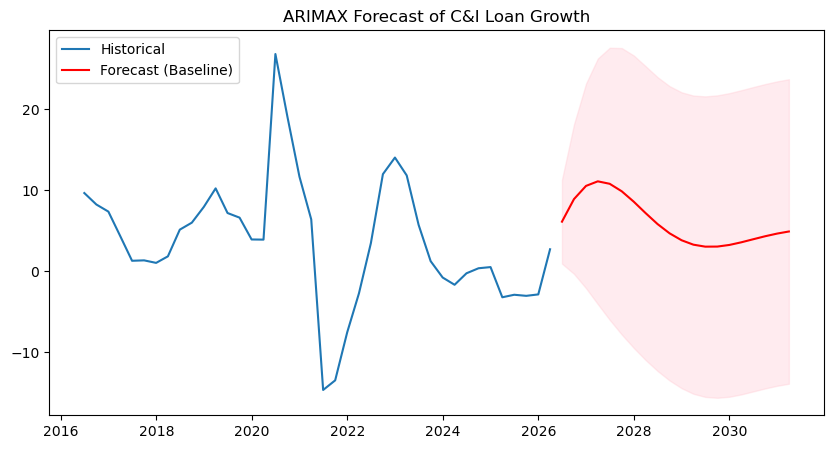

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# ---------------------------------------------------------
# 1. ROBUST FRED DATA CLEANING (Fixes the TypeError)
# ---------------------------------------------------------
def clean_fred_data(file_path, value_col_name):
    # Read CSV
    df = pd.read_csv(file_path)
    
    # Dynamically find the date column (usually 'observation_date' or 'DATE')
    date_col = [c for c in df.columns if 'date' in c.lower()][0]
    
    # Convert to datetime and set as index
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col)
    
    # FORCE NUMERIC: Coerce errors to NaN (e.g., "." or "ND") and drop non-numeric cols
    # This prevents the "agg function failed" error on object columns
    df_numeric = df.apply(pd.to_numeric, errors='coerce')
    
    # Resample to Quarterly Mean (handles missing values automatically)
    df_q = df_numeric.resample('Q').mean()
    
    # Rename the single column to our target name
    df_q.columns = [value_col_name]
    return df_q

# Load FRED Data
try:
    df_loans = clean_fred_data('BUSLOANS.csv', 'Loans_Billions')
    df_cpi = clean_fred_data('CPI.csv', 'CPI')
    df_unemp = clean_fred_data('UNEMPLOYMENT.csv', 'Unemployment_Rate')
    
    # Create the Master History DataFrame
    df_history = pd.concat([df_loans, df_cpi, df_unemp], axis=1).dropna()
    
    # Feature Engineering (Growth Rates for Stationarity)
    df_history['Loan_Growth'] = df_history['Loans_Billions'].pct_change(4) * 100
    df_history['Inflation'] = df_history['CPI'].pct_change(4) * 100
    df_history = df_history.dropna()
    
    print("✅ Historical Data Loaded Successfully!")
    print(df_history.head())

except Exception as e:
    print(f"❌ Error Loading FRED Data: {e}")

# ---------------------------------------------------------
# 2. LOAD NGFS SCENARIO DATA (The "X" Variables)
# ---------------------------------------------------------
ngfs_file = 'Downscaled_REMIND-MAgPIE 3.3-4.8_data.xlsx - data.csv'

def load_ngfs_scenario(file_path, scenario_name, region_code='USA'):
    try:
        df = pd.read_csv(file_path)
        
        # Filter for Region and Scenario
        # Note: Adjust 'USA' to 'United States' if needed based on file content
        mask = (df['Region'] == region_code) & (df['Scenario'] == scenario_name)
        df_sub = df[mask].copy()
        
        # Melt to Long Format (Years as Rows)
        year_cols = [c for c in df_sub.columns if c.isdigit()]
        df_melt = df_sub.melt(id_vars=['Variable'], value_vars=year_cols, 
                              var_name='Year', value_name='Value')
        
        df_melt['Year'] = pd.to_datetime(df_melt['Year'].astype(str) + '-12-31')
        
        # Pivot to get Variables as Columns
        df_pivot = df_melt.pivot(index='Year', columns='Variable', values='Value')
        
        # Interpolate to Quarterly (Linear fill between 5-year steps)
        df_q = df_pivot.resample('Q').interpolate(method='linear')
        
        return df_q
    except Exception as e:
        print(f"Error loading NGFS {scenario_name}: {e}")
        return None

# Load 'Net Zero 2050' (or 'Below 2C') and 'Delayed transition'
df_ngfs_nz = load_ngfs_scenario(ngfs_file, 'Net Zero 2050')
df_ngfs_delayed = load_ngfs_scenario(ngfs_file, 'Delayed transition')

# Select Key Driver: Carbon Price (as proxy for transition risk)x
# Note: You might need to use 'GDP|PPP' or similar if Carbon Price is 0 in history
target_driver = 'Price|Carbon' 

# ---------------------------------------------------------
# 3. FIT ARIMAX MODEL (Loans ~ History + Shocks)
# ---------------------------------------------------------
# Define Endogenous (Y) and Exogenous (X)
# We use Unemployment as a proxy for the economic cycle
y_train = df_history['Loan_Growth']
X_train = df_history[['Unemployment_Rate']] 

# Initialize ARIMA (p=1, d=0, q=1 is a standard starting point)
# exog=X_train adds the "X" (Regression) part
model = ARIMA(y_train, exog=X_train, order=(2, 0, 1))
model_fit = model.fit()

print("\n✅ Model Trained!")
print(model_fit.summary())

# ---------------------------------------------------------
# 4. FORECAST SCENARIOS (The Stress Test)
# ---------------------------------------------------------
# To forecast, we need Future X values. 
# Since NGFS doesn't have 'Unemployment_Rate', we assume a simple relationship 
# or use NGFS GDP as a proxy. For this demo, let's assume Unemployment stays flat
# or we use a dummy path to show the code mechanics.

steps = 20 # Forecast 5 years (20 quarters)
future_dates = pd.date_range(start=df_history.index[-1], periods=steps+1, freq='Q')[1:]

# Create a Dummy Future X (Replace this with mapped NGFS GDP data!)
future_X = pd.DataFrame(index=future_dates)
future_X['Unemployment_Rate'] = 4.0 # Assume 4% unemployment flat

# Forecast
forecast = model_fit.get_forecast(steps=steps, exog=future_X)
pred_mean = forecast.predicted_mean
pred_conf = forecast.conf_int()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(df_history.index[-40:], df_history['Loan_Growth'][-40:], label='Historical')
plt.plot(pred_mean.index, pred_mean, label='Forecast (Baseline)', color='red')
plt.fill_between(pred_mean.index, pred_conf.iloc[:, 0], pred_conf.iloc[:, 1], color='pink', alpha=0.3)
plt.title('ARIMAX Forecast of C&I Loan Growth')
plt.legend()
plt.show()